In [2]:
import kagglehub
import shutil
import os

# Скачиваем датасет
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")



/Users/moymarmois/school 21/Studying/UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V17/herculeh/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(path)

/Users/moymarmois/.cache/kagglehub/datasets/austinreese/craigslist-carstrucks-data/versions/10


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

In [5]:
df = pd.read_csv(os.path.join(path, "vehicles.csv"))

In [ ]:
df.shape

(426880, 26)

In [ ]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [6]:
df = df.drop(["url", "region_url", "county", "VIN", "image_url"], axis=1).set_index("id")

In [7]:
df["posting_date"] = pd.to_datetime(df["posting_date"], format="mixed", utc=True).dt.year

In [8]:
df = pd.get_dummies(df, columns=["fuel"], drop_first=True, dtype="int")
df = pd.get_dummies(df, columns=["manufacturer"], drop_first=True, dtype="int")

,model,count
0,f-150,8009
1,silverado 1500,5140
2,1500,4211
3,camry,3135
4,silverado,3023
...,...,...
29662,rx& gls sport,1
29663,ATI,1
29664,gand wagoneer,1
29665,96 Suburban,1


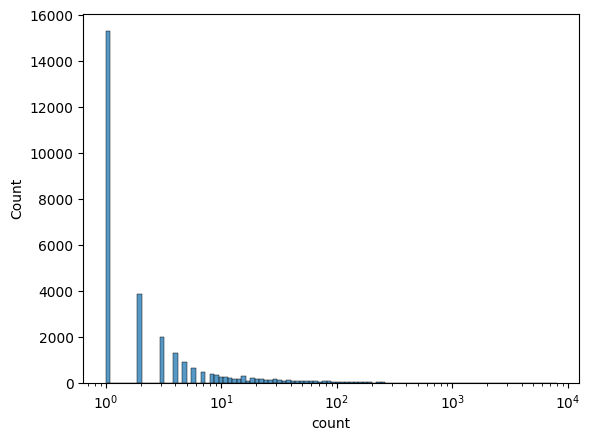

In [27]:
freq = df["model"].value_counts().reset_index()
sns.histplot(freq["count"], bins=100, log_scale=True)
freq

In [ ]:
top_model = df["model"].value_counts().head(50).index
df["model_clean"] = df["model"].where(df["model"].isin())

In [41]:
df.dropna().head()

,region,price,year,manufacturer,model,condition,cylinders,odometer,title_status,transmission,...,paint_color,description,state,lat,long,posting_date,fuel_electric,fuel_gas,fuel_hybrid,fuel_other
id,,,,,,,,,,,,,,,,,,,,,
7316356412,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,128000.0,clean,automatic,...,black,2013 F-150 XLT V6 4 Door. Good condition. Leve...,al,32.592000,-85.51890,2021.0,0,1,0,0
7314560853,auburn,19900,2004.0,ford,f250 super duty,good,8 cylinders,88000.0,clean,automatic,...,blue,Here I have a unmolested Ford F-250 6.0 power ...,al,32.547500,-85.46820,2021.0,0,0,0,0
7313406529,auburn,14000,2012.0,honda,odyssey,excellent,6 cylinders,95000.0,clean,automatic,...,silver,"Readily available. Excellent condition, clean ...",al,32.628739,-85.46182,2021.0,0,1,0,0
7312847466,auburn,22500,2001.0,ford,f450,good,8 cylinders,144700.0,clean,manual,...,white,"Ford Super Duty F450 , XL with King Ranch seat...",al,32.630400,-85.40160,2021.0,0,0,0,0
7312144944,auburn,15000,2017.0,dodge,charger rt 4dr sedan,excellent,8 cylinders,90000.0,rebuilt,automatic,...,grey,"2017 dodge charger rt runs great $15,000.00",al,32.822400,-85.77040,2021.0,0,1,0,0


In [7]:
df_corr = df.corr(numeric_only=True)["price"].sort_values()
df_corr

year       -0.004925
long       -0.000408
lat         0.000357
odometer    0.010032
price       1.000000
Name: price, dtype: float64

In [8]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'image_url', 'description',
       'state', 'lat', 'long', 'posting_date'],
      dtype='str')

In [ ]:
# X = df.drop("price", axis=1)
# y = df["price"]

In [ ]:
def found_miss(df):
  percent_na = np.round(100 * df.isna().sum() / len(df), 2)

  return percent_na[percent_na > 0].sort_values()

/tmp/ipykernel_6127/3739375903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");


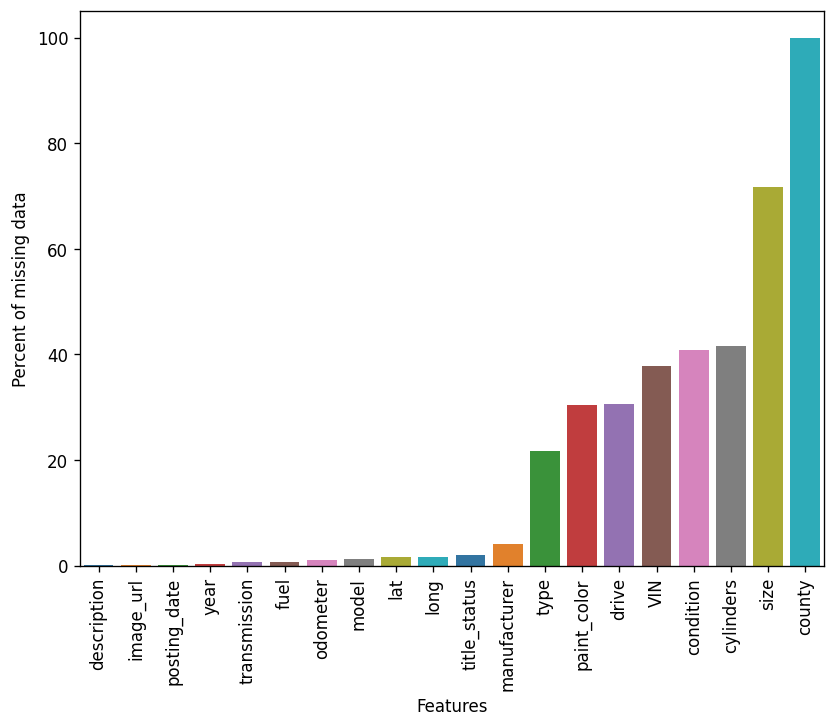

In [ ]:
plt.figure(figsize=(8,6), dpi=120);
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features");
plt.ylabel("Percent of missing data");
plt.xticks(rotation=90);
plt.show();

/tmp/ipykernel_6127/605149035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");


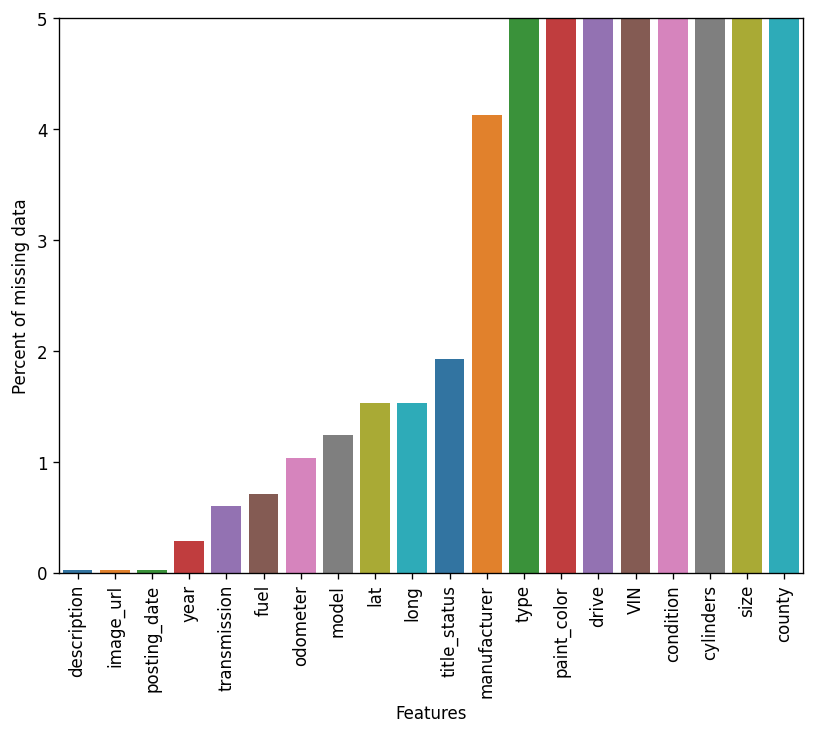

In [ ]:
plt.figure(figsize=(8,6), dpi=120);
plt.ylim(0,5)
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features")
plt.ylabel("Percent of missing data")
plt.xticks(rotation=90);
plt.show();

In [ ]:
df[["image_url", "description", "posting_date"]].isna().sum()

,0
image_url,68
description,70
posting_date,68


In [ ]:
df.shape

(426880, 23)

In [ ]:
df = df.dropna(subset="description")
df.shape

(426810, 23)

In [ ]:
df["year"].isna().sum()

np.int64(1137)

In [ ]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'image_url', 'description',
       'county', 'state', 'lat', 'long', 'posting_date'],
      dtype='object')

In [ ]:
df["year"].isna().sum()

np.int64(1137)

In [ ]:
df["year"] = df.groupby(["manufacturer", "model"], dropna=False)["year"].transform(lambda x: x.fillna(x.median()))
df["year"].isna().sum()

np.int64(1011)

/tmp/ipykernel_6127/605149035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");


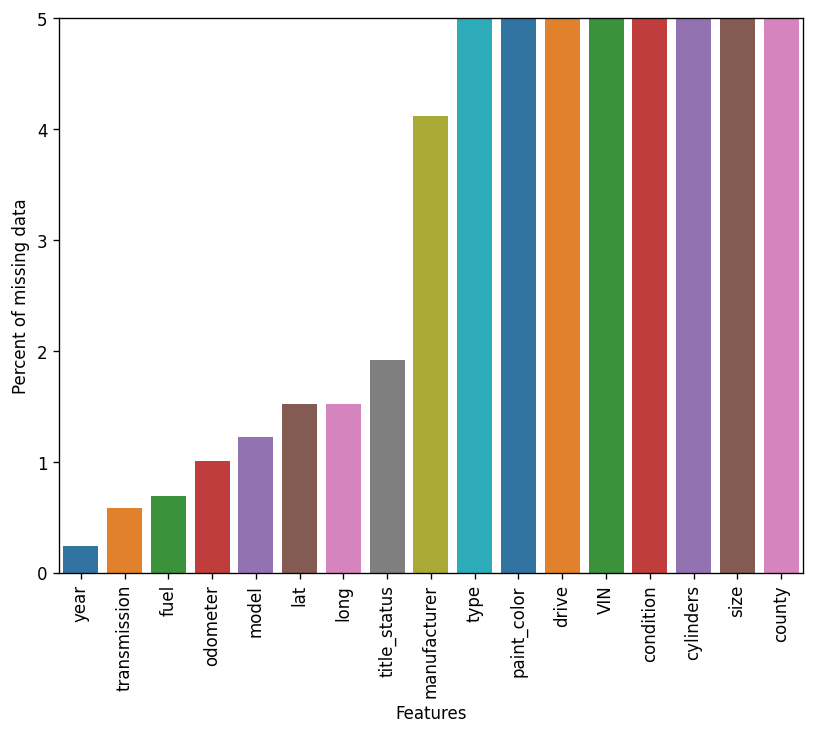

In [ ]:
plt.figure(figsize=(8,6), dpi=120);
plt.ylim(0,5)
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features")
plt.ylabel("Percent of missing data")
plt.xticks(rotation=90);
plt.show();

In [ ]:
df_copy= df.copy()
df_copy["cylinders"] = df_copy["cylinders"].str.split().str[0]
df_copy["cylinders"].unique()

array(['8', '6', nan, '4', '5', 'other', '3', '10', '12'], dtype=object)

In [ ]:
df["VIN"].head()

,VIN
id,
7316814884,3GTP1VEC4EG551563
7316814758,1GCSCSE06AZ123805
7316814989,3GCPWCED5LG130317
7316743432,5TFRM5F17HX120972
7316356412,NaN
